# EMIT Fractional Cover Analysis

Written by Kelly Luis and Gil Lopez

Description: This notebook reviews how to setup your python environment to query, open, and analyze EMIT L2B Fractional Cover data. This is a work in progress over Summer 2026

## What this notebook does?
1. Searches NASA Earthdata (CMR) for EMIT L2B Fractional Cover granules over a bounding
   box + date range — edit `bbox` / `temporal` in the Search cell to point at a
   different region/time.
2. Downloads every matching granule's 7 GeoTIFFs (PV/NPV/BARE fraction, their 3
   uncertainty bands, 1 QC band).
3. Applies the QC band as a mask (drops cloud/urban/water/snow-ice pixels) uniformly
   across the fraction + uncertainty bands.
4. Mosaics every granule the search found into one continuous scene and visualizes it.
5. Exports the mosaic as analysis-ready GeoTIFFs.

## Reference docs
- EMIT L2B Fractional Cover User Guide: https://github.com/emit-sds/emit-sds-frcov/blob/main/docs/EMIT_L2B_Fractional_Cover_User_Guide.md
- QC flag integer codes used below were reverse-engineered from
  `singleband_raster_hierarchy()` in `create_frcov_masks.py` at
  https://github.com/emit-sds/emit-sds-frcov — the User Guide names the flag
  categories (cloud, urban, water, snow/ice) but doesn't publish the codes. If EMIT-SDS
  ever formalizes these in the ATBD itself, prefer that over this notebook's values.

## Setup

### 1. Create the conda/mamba environment
This notebook needs a geospatial Python stack (GDAL, rasterio, rioxarray, earthaccess,
etc.) that's much easier to manage with conda/mamba than plain pip/venv.

From the repo root, in a terminal:
```
mamba env create -f environment.yml
mamba activate emit-fcov
```
Already have the `emit-fcov` env and just pulled changes to `environment.yml`?
```
mamba env update -n emit-fcov -f environment.yml --prune
```
Then point this notebook's kernel at the `emit-fcov` env (kernel picker in the notebook
toolbar). **If imports fail right after creating/updating the env, restart the kernel** —
a running kernel process won't pick up newly installed/changed packages on its own.

### 2. NASA Earthdata credentials
`earthaccess.login()` below needs an Earthdata Login account. Either let it prompt you
interactively the first time (`earthaccess.login(persist=True)` saves the result to
`~/.netrc` so you won't be asked again), or set `EARTHDATA_USERNAME` /
`EARTHDATA_PASSWORD` env vars yourself. No account? Register free at
https://urs.earthdata.nasa.gov/.


## Step 1: Load Libraries

In [1]:
# Import Libraries
import os
import earthaccess
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

/Users/kluis/miniforge3/envs/emit-fcov/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# QC flag codes -- from singleband_raster_hierarchy() in create_frcov_masks.py,
# https://github.com/emit-sds/emit-sds-frcov (not formally published in the User Guide).
# Hierarchical: each pixel gets the FIRST condition below that applies to it.
flag_labels = {
    0: "clear",
    1: "cloud_or_cirrus",
    2: "urban",
    3: "water_or_coastal",
    4: "snow_ice",
}  # -9999 = nodata (outside scene footprint); handled separately via masked=True on load

flag_colors = ["#2ca02c", "#7f7f7f", "#d62728", "#1f77b4", "#f2f2f2"]
cmap = ListedColormap(flag_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

In [3]:
# Authenticate with NASA Earthdata (reads ~/.netrc, or prompts + persists on first run)
auth = earthaccess.login(persist=True)

In [4]:
# EMIT L2B Fractional Cover & Uncertainty (60 m, V001) over Maui.
# Currently narrowed to the exact acquisition date (2025-08-17) of the granule from
# https://search.earthdata.nasa.gov/...&g=G3991818701-LPCLOUD -- widen `temporal`
# (e.g. back to a month-long window) to search more broadly.
bbox = (-156.74918, 20.47418, -155.83513, 21.09401)  # (lon_min, lat_min, lon_max, lat_max)
temporal = ("2025-08-16", "2025-08-18")

results = earthaccess.search_data(
    concept_id="C3911089796-LPCLOUD",  # EMIT_L2BFRCOV.001 collection (LPCLOUD)
    bounding_box=bbox,
    temporal=temporal,
)

print(f"Found {len(results)} granule(s)")

Found 2 granule(s)


/Users/kluis/miniforge3/envs/emit-fcov/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [5]:
# Print every file (granule ID + all associated data/browse links) found in the search
for granule in results:
    print(granule["meta"]["native-id"])
    for link in granule.data_links():
        print(f"  {link}")

EMIT_L2B_FRCOV_001_20250817T233321_2522915_004
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVQC_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVPV_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVPVUNC_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVNPV_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVNPVUNC_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-p

## Step 2: Locally download granules of interest

For every granule the search above found, there are 7 GeoTIFFs to download. Load them into one
 `xarray.Dataset`, and apply the QC band as a mask across the fraction
(PV/NPV/BARE) and uncertainty bands.

In [6]:
def download_and_reconcile(granule):
    """Download a granule's 7 GeoTIFFs, load into one aligned Dataset, mask
    fraction + uncertainty bands to QC-clear pixels (qc == 0). Returns (ds, ds_clear).
    QC flag source: create_frcov_masks.py in github.com/emit-sds/emit-sds-frcov."""
    granule_id = granule["meta"]["native-id"]
    out_dir = os.path.join("data", "emit_fcov", granule_id)
    os.makedirs(out_dir, exist_ok=True)
    files = earthaccess.download([granule], local_path=out_dir)

    roles = {}
    for f in files:
        name = os.path.basename(f)
        if "FRCOVQC" in name:
            roles["qc"] = f
        elif "FRCOVPVUNC" in name:
            roles["pv_unc"] = f
        elif "FRCOVNPVUNC" in name:
            roles["npv_unc"] = f
        elif "FRCOVBAREUNC" in name:
            roles["bare_unc"] = f
        elif "FRCOVPV" in name:
            roles["pv"] = f
        elif "FRCOVNPV" in name:
            roles["npv"] = f
        elif "FRCOVBARE" in name:
            roles["bare"] = f
    assert len(roles) == 7, f"Expected 7 bands, matched {len(roles)}: {roles}"

    g_ds = xr.Dataset(
        {role: rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
         for role, path in roles.items()}
    )

    clear = g_ds["qc"] == 0  # only unflagged pixels are retrieval-valid per the ATBD mask hierarchy
    g_ds_clear = g_ds.copy()
    for v in ["pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]:
        g_ds_clear[v] = g_ds[v].where(clear)

    return g_ds, g_ds_clear

In [7]:
# Process every granule the search found (not just one hardcoded scene) so this
# notebook still works if you change the bbox/temporal window above.
granules = {}
for g in results:
    gid = g["meta"]["native-id"]
    print(f"Processing {gid} ...")
    g_ds, g_ds_clear = download_and_reconcile(g)
    granules[gid] = (g_ds, g_ds_clear)

    total = int(g_ds["qc"].notnull().sum())
    n_clear = int((g_ds["qc"] == 0).sum())
    print(f"  {n_clear}/{total} pixels clear ({100 * n_clear / total:.1f}%)")

print(f"\nReconciled {len(granules)} granule(s).")

/Users/kluis/miniforge3/envs/emit-fcov/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


Processing EMIT_L2B_FRCOV_001_20250817T233321_2522915_004 ...


QUEUEING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 2261.78it/s]
PROCESSING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 18001.30it/s]
COLLECTING RESULTS | : 100%|██████████| 7/7 [00:00<00:00, 89512.59it/s]
/Users/kluis/miniforge3/envs/emit-fcov/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


  376214/1966749 pixels clear (19.1%)
Processing EMIT_L2B_FRCOV_001_20250817T233333_2522915_005 ...


QUEUEING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 6566.79it/s]
PROCESSING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 111212.61it/s]
COLLECTING RESULTS | : 100%|██████████| 7/7 [00:00<00:00, 132252.83it/s]


  100198/1909122 pixels clear (5.2%)

Reconciled 2 granule(s).


# Mosaic All Scenes

Merge every granule's QC-masked Dataset into one continuous mosaic. Works for any number
of granules (1..N) — if the search above returns a single scene the "mosaic" is just
that scene; if it returns several, they all get merged into one.

In [8]:
mosaic_vars = ["qc", "pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]

ds_mosaic = xr.Dataset({
    v: merge_arrays([g_ds_clear[v] for _, g_ds_clear in granules.values()], nodata=np.nan)
    for v in mosaic_vars
})

print(f"Mosaicked {len(granules)} scene(s) -> shape {ds_mosaic['pv'].shape}")

frac_sum = ds_mosaic["pv"] + ds_mosaic["npv"] + ds_mosaic["bare"]
print(f"Mosaic PV+NPV+BARE (clear pixels) -> mean: {float(frac_sum.mean(skipna=True)):.4f}, "
      f"std: {float(frac_sum.std(skipna=True)):.4f} (should be ~1.0 / ~0)")

Mosaicked 2 scene(s) -> shape (3096, 2829)
Mosaic PV+NPV+BARE (clear pixels) -> mean: 1.0000, std: 0.0000 (should be ~1.0 / ~0)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


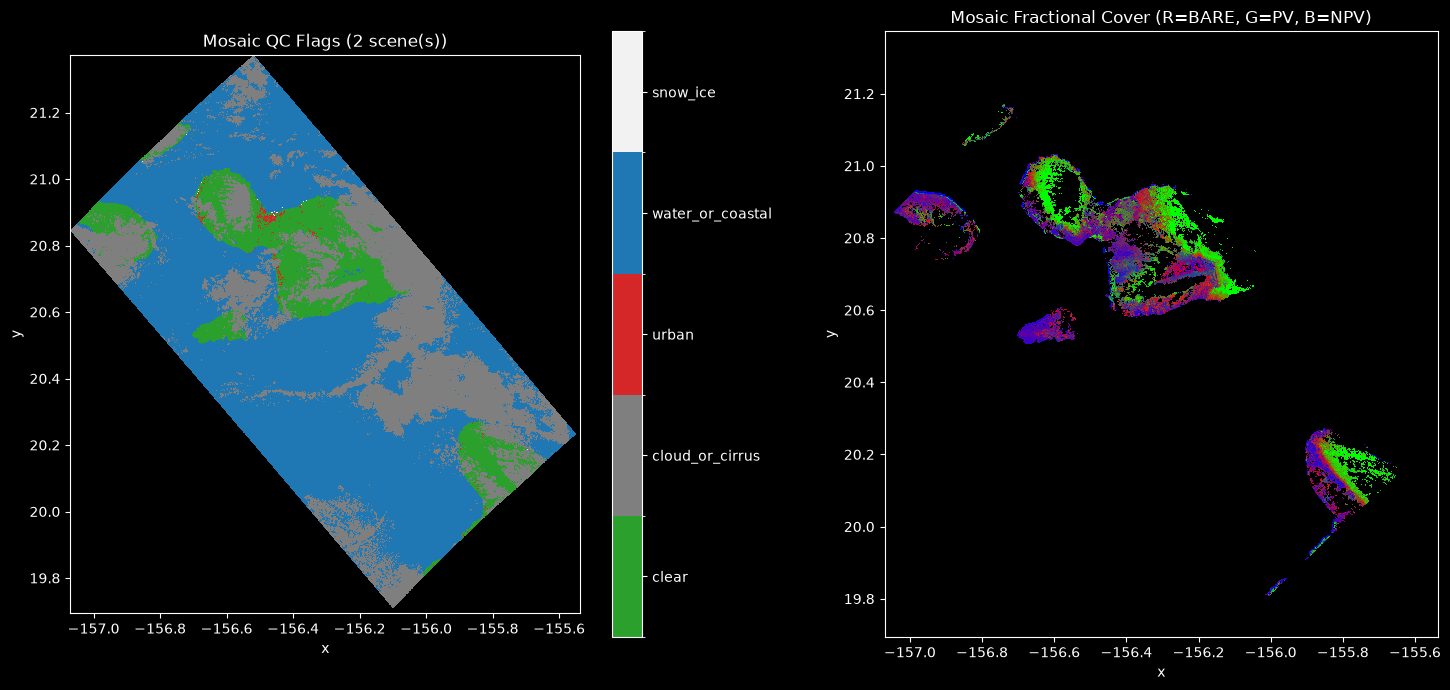

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = ds_mosaic["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title(f"Mosaic QC Flags ({len(granules)} scene(s))")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

rgb_mosaic = xr.concat(
    [ds_mosaic["bare"].fillna(0), ds_mosaic["pv"].fillna(0), ds_mosaic["npv"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb_mosaic.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Mosaic Fractional Cover (R=BARE, G=PV, B=NPV)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

# Export Mosaic (Analysis-Ready GeoTIFFs)

Write the QC-masked mosaic bands back out as GeoTIFFs so this pipeline doesn't need to be
rerun (and Earthdata re-downloaded) just to reload the result later, e.g. in QGIS.

In [10]:
export_dir = os.path.join("data", "processed")
os.makedirs(export_dir, exist_ok=True)

for var in mosaic_vars:
    out_path = os.path.join(export_dir, f"emit_fcov_mosaic_{var}.tif")
    da = ds_mosaic[var]
    # qc is integer-dtype -- reuse its native -9999 nodata sentinel (see flag_labels
    # comment above) since NaN isn't representable in an int raster. Everything else
    # (fraction + uncertainty bands) is float, so NaN is fine.
    nodata = -9999 if var == "qc" else np.nan
    # Both attrs and encoding can carry a stale _FillValue (attrs from write_nodata()
    # below, encoding inherited from open_rasterio(masked=True) via merge_arrays) --
    # to_raster()'s CF encoder refuses to reconcile them itself, so clear both first.
    da.attrs.pop("_FillValue", None)
    da.encoding.pop("_FillValue", None)
    if var == "qc":
        da = da.fillna(nodata).astype("int16")
    da.rio.write_nodata(nodata, inplace=True)
    da.rio.to_raster(out_path, compress="LZW")
    print(f"Wrote {out_path}")

Wrote data/processed/emit_fcov_mosaic_qc.tif
Wrote data/processed/emit_fcov_mosaic_pv.tif
Wrote data/processed/emit_fcov_mosaic_npv.tif
Wrote data/processed/emit_fcov_mosaic_bare.tif
Wrote data/processed/emit_fcov_mosaic_pv_unc.tif
Wrote data/processed/emit_fcov_mosaic_npv_unc.tif
Wrote data/processed/emit_fcov_mosaic_bare_unc.tif


# Preliminary Stats

Quick, first look descriptive stats per band, plus a dominant-cover-class breakdown (whichever of
PV/NPV/BARE is highest per pixel), all computed over the mosaic's clear pixels only.

### What does `*_unc` mean?

Per [the ATBD, section 6.2](https://github.com/emit-sds/emit-sds-frcov/blob/main/docs/EMIT_L2B_Fractional_Cover_ATBD.md#62-uncertainties):
PV/NPV/BARE come from a Monte Carlo spectral mixture analysis -- each pixel is unmixed many
times, reseeding which spectral endmembers get picked and perturbing the L2A reflectance
per-wavelength by an amount proportional to its L2A uncertainty. `pv_unc` / `npv_unc` /
`bare_unc` is the **standard deviation of that band's fraction across all the Monte Carlo
runs**, in the same 0-1 units as the fraction itself -- e.g. `pv_unc = 0.05` means the PV
estimate for that pixel had ~5 percentage points of spread across simulations.

- Low `*_unc` -> retrieval was stable regardless of which endmembers/reflectance noise got
  sampled (more trustworthy).
- High `*_unc` -> small changes in endmember choice or reflectance noise swing the fraction a
  lot (mixed pixels, atypical spectra, or a poorly-matched endmember library).

This is independent of `qc`: QC drops clouds/urban/water/snow-ice outright, while `*_unc`
scores retrieval confidence on whatever pixels QC left in.

In [11]:
# Per-band descriptive stats (fractions are unitless 0-1; uncertainty is in the same units)
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var]
    unc = ds_mosaic[f"{var}_unc"]
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

# Dominant cover class per pixel (whichever of PV/NPV/BARE has the highest fraction there)
stacked = xr.concat(
    [ds_mosaic["pv"], ds_mosaic["npv"], ds_mosaic["bare"]], dim="band"
).assign_coords(band=["pv", "npv", "bare"])
dominant = stacked.idxmax(dim="band")

n_valid = int(dominant.notnull().sum())
print(f"\nDominant cover class ({n_valid} clear pixels):")
for label in ["pv", "npv", "bare"]:
    n = int((dominant == label).sum())
    print(f"  {label:5s}: {n:8d}  ({100 * n / n_valid:5.1f}%)")

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.3641  0.2344  0.3433  0.0  1.0            0.0420
npv   0.3159  0.2925  0.2719  0.0  1.0            0.1466
bare  0.3200  0.3087  0.2192  0.0  1.0            0.1432

Dominant cover class (476237 clear pixels):
  pv   :   171302  ( 36.0%)
  npv  :   167145  ( 35.1%)
  bare :   137790  ( 28.9%)
